# CC5061NI – Applied Data Science
## Diwali Sales Transaction Data – Analysis Notebook
**Student Name:** Bikram Tamang  
**London Met ID:** 24046576
**Submission Date:** Apr 3, 2026  
**Module Code:** CC5061NI

# Section 1 Data Understanding

In [30]:
# -------------------------------------------------------
# Import all required libraries
# -------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency

print('All libraries imported successfully.')

All libraries imported successfully.


In [31]:
# Load the dataset using latin-1 encoding to handle special characters present in the file

df_raw = pd.read_csv('DiwaliSalesData_264932.csv', encoding='latin1')
print("Shape fo the Dataset: ", df_raw.shape)
df_raw.head()

Shape fo the Dataset:  (11251, 15)


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


### 1.1 Dataset Overview

The Diwali Sales Dataset is a retail/e-commerce transactional dataset capturing customer purchase behaviour during the Diwali festive season in India. Each row represents a single sales transaction made by a customer, recording demographic attributes (gender, age, marital status, occupation, state) alongside transactional details (product category, number of orders, and purchase amount). The primary objective of this analysis is to understand sales patterns, identify high-value customer segments, detect data quality issues, and draw actionable business insights through statistical and visual exploration.

### 1.2. Data Interpretation

In [32]:
print("The data types of all the coulumns are given below: ")
print(df_raw.dtypes)

print()
print("Dataset Info: ")
df_raw.info()

The data types of all the coulumns are given below: 
User_ID               int64
Cust_name            object
Product_ID           object
Gender               object
Age Group            object
Age                   int64
Marital_Status        int64
State                object
Zone                 object
Occupation           object
Product_Category     object
Orders                int64
Amount              float64
Status              float64
unnamed1            float64
dtype: object

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital

**Interpretation:** The dataset contains 11,251 rows and 15 columns.
The `head()` output confirms the data was loaded without formatting errors. Key columns such as `Amount`, `Orders`, and `Product_Category` are clearly visible.

In [33]:
# Check memory usage of the dataframe
memory_bytes = df_raw.memory_usage(deep=True).sum()
memory_mb = memory_bytes / (1024 * 1024)
print('Total memory occupied by dataset: ' + str(round(memory_mb, 2)) + ' MB')

Total memory occupied by dataset: 5.48 MB


In [34]:
# Data Description Garnu xa


**Data Description Table:**

| Column Name | Data Type | Description | Potential Issues |
|---|---|---|---|
| User_ID | Integer | Unique customer identifier | May be dropped (not analytical) |
| Cust_name | String | Customer full name | Dropped for privacy |
| Product_ID | String | Unique product identifier | May be dropped |
| Gender | String | Customer gender (M/F) | None identified |
| Age Group | String | Age bracket of customer | Needs ordinal encoding |
| Age | Integer | Exact age in years | None identified |
| Marital_Status | Integer | 0 = Single, 1 = Married | Binary; should be confirmed |
| State | String | Indian state of customer | None identified |
| Zone | String | Geographic zone (N/S/E/W/Central) | None identified |
| Occupation | String | Customer's occupation sector | None identified |
| Product_Category | String | Category of purchased product | None identified |
| Orders | Integer | Number of items ordered | None identified |
| Amount | Float | Total purchase value in INR | 12 missing values |
| Status | Float | Entirely null – artifact column | Drop entirely |
| unnamed1 | Float | Entirely null – artifact column | Drop entirely |

### 1.3 Identified Data Quality Challenges

In [35]:
# Check missing values across all columns
print(' Missing Values Per Column ')
print()
missing_counts = df_raw.isnull().sum()
print(missing_counts)

 Missing Values Per Column 

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64


**Interpretation:** Three key challenges are identified:

(1) `Amount` has 12 missing values, these rows must be dropped as Amount is the primary outcome variable;

(2) `Status` and `unnamed1` are entirely null across all 11,251 rows, making them meaningless artefact columns;

(3) `Age Group` is stored as an unordered string and requires ordinal encoding before any age-based analysis.

In [36]:
# -------------------------------------------------------
# Re-load dataset cleanly for the preparation stage.
# The file uses latin-1 encoding (also known as iso-8859-1)
# which handles special Indian language characters.
# -------------------------------------------------------
df = pd.read_csv('DiwaliSalesData_264932.csv', encoding='latin-1')

print('Dataset loaded.')
print('Number of rows: ' + str(df.shape[0]))
print('Number of columns: ' + str(df.shape[1]))
df.head()

Dataset loaded.
Number of rows: 11251
Number of columns: 15


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


## Section 2 – Data Preparation






### 2.1 Import the Dataset

In [37]:



# Re-load dataset cleanly for the preparation stage.
# The file uses latin-1 encoding which handles special Indian language characters.
df = pd.read_csv('DiwaliSalesData_264932.csv', encoding='latin-1')

print('Dataset loaded.')
print('Number of rows: ' + str(df.shape[0]))
print('Number of columns: ' + str(df.shape[1]))
print()
df.head()

Dataset loaded.
Number of rows: 11251
Number of columns: 15



,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


**Interpretation:** The dataset contains 11,251 rows and 15 columns. The `head()` output confirms that the data was loaded without formatting errors and all column headers are correctly identified.

## 2.2. Data Insight

In [38]:
# Examine the structure of the dataset in detail
# number of rows, columns, data types, and null counts
print(' df.info()')
df.info()
print()
print()
print(' df.dtypes ')
print(df.dtypes)

 df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


 df.dtypes 
User_


**Business Relevance of Key Columns:**

| Column | Business Relevance |
|---|---|
| Amount | Reflects total sales revenue generated per transaction. This is the primary measure of sales performance. |
| Orders | Indicates how many items were purchased in one transaction. Higher orders suggest bulk buying behaviour. |
| Product_Category | Identifies which product segment drives the most revenue, helping with inventory and marketing decisions. |
| Zone | Reveals geographic patterns in sales, enabling region-specific promotions and stock planning. |
| Occupation | Helps profile high-spending customer groups by their professional background. |
| Age Group | Segments customers by life stage, guiding targeted marketing campaigns. |
| Marital_Status | Can indicate differences in spending priorities between single and married customers. |

# Section - 3 : Data Cleaning

### 3.1 Convert Age Group to Ordinal Categorical

In [39]:
age_label_map = {
    '0-17':  'Teen',
    '18-25': 'Youth',
    '26-35': 'Adult',
    '36-45': 'Adult',        # merge with above
    '46-50': 'Senior',
    '51-55': 'Senior',       # merge with above
    '55+':   'Elder'
}

age_order = ['Teen', 'Youth', 'Adult', 'Senior', 'Elder']

df['Age Group'] = df['Age Group'].map(age_label_map)
df['Age Group'] = pd.Categorical(df['Age Group'], categories=age_order, ordered=True)

print('Value counts:')
print(df['Age Group'].value_counts().sort_index())

Value counts:
Age Group
Teen       296
Youth     1879
Adult     6829
Senior    1819
Elder      428
Name: count, dtype: int64


**Explanation:** `pd.Categorical()` with `ordered=True` was used to preserve the meaningful sequence of age groups (0-17 being the youngest bracket, 55+ the oldest). Ordinal encoding matters for analysis because it enables meaningful comparisons, such as verifying that spending patterns increase from younger to older age groups, and ensures that visualisations display groups in the correct order rather than alphabetically.

### 3.2 Create Purchase_Value_Category Column

In [40]:
"""
Create a new column that categorises each transaction's Amount into Low, Medium, or High based on thresholds
derived from the 33rd and 66th percentiles of Amount.

Low:    0   – 6908  (bottom third)
Medium: 6908 – 11065 (middle third)
High:   11065+       (top third)
"""

low_threshold = 6908
high_threshold = 11065

bin_edges = [0, low_threshold, high_threshold, df['Amount'].max() + 1]
bin_labels = ['Low', 'Medium', 'High']

df['Purchase_Value_Category'] = pd.cut(df['Amount'], bins=bin_edges, labels=bin_labels)

print('Purchase_Value_Category value counts:')
print(df['Purchase_Value_Category'].value_counts())
print()
df[['Amount', 'Purchase_Value_Category']].head(10)

Purchase_Value_Category value counts:
Purchase_Value_Category
High      3821
Low       3712
Medium    3706
Name: count, dtype: int64



,Amount,Purchase_Value_Category
0,23952.00,High
1,23934.00,High
2,23924.00,High
3,23912.00,High
4,23877.00,High
5,23877.00,High
6,23841.00,High
7,NaN,NaN
8,23809.00,High
9,23799.99,High


**Explanation:** The thresholds (6,908 and 11,065) were chosen based on the 33rd and 66th percentile values of the `Amount` column, creating three roughly equal-sized groups. This percentile-based approach avoids arbitrary thresholds and ensures each category contains a meaningful number of transactions. `pd.cut()` partitions the continuous `Amount` variable into discrete categories, which is useful for grouped comparisons, visualisations, and segmentation-based analysis.

### 3.3 Drop Irrelevant Columns

In [41]:
# Remove columns that are not useful for analysis.
# Columns being dropped and reasons:
#   - Cust_name : personal identifier, no analytical value
#   - Status    : entirely null, artefact column
#   - unnamed1  : entirely null, artefact column


columns_to_drop = ['Cust_name', 'Status', 'unnamed1']

df = df.drop(columns=columns_to_drop)

print('Columns remaining after drop:')
print(df.columns.tolist())
print('New shape:', df.shape)

Columns remaining after drop:
['User_ID', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount', 'Purchase_Value_Category']
New shape: (11251, 13)


**Explanation:** Three columns were removed. `Cust_name` contains personal identifiers that are not relevant to sales pattern analysis and may introduce privacy concerns. `Status` and `unnamed1` are artefact columns containing no data at all (100% null across 11,251 rows) — they likely represent unintended extra columns introduced during data export and carry zero analytical value.

### 3.4 Handle Missing Values

In [42]:
# Techniques for handling missing values:

# 1. Deletion (dropna): Remove rows with null values in
#    critical columns. Best when missing data is random
#    and rows are few.

# 2. Mean/Median Imputation: Replace nulls with the
#    average or median of that column. Suitable for
#    numerical columns where the missing proportion is small.

# 3. Mode Imputation: Replace nulls with the most
#    frequent value. Used for categorical columns.

# 4. Forward/Backward Fill: Propagate the previous or
#    next known value. Useful for time-series data.

# In this dataset, Amount is the primary outcome variable.
# Imputing sales figures would introduce statistical bias,
# so we choose deletion for the 12 affected rows.

rows_before = len(df)

# Drop rows where Amount is null (12 rows)
df = df.dropna(subset=['Amount'])

rows_after = len(df)
rows_dropped = rows_before - rows_after

print('Rows before cleaning: ' + str(rows_before))
print('Rows after cleaning:  ' + str(rows_after))
print('Rows dropped:         ' + str(rows_dropped))
print()
print('Remaining missing values:')
print(df.isnull().sum())

Rows before cleaning: 11251
Rows after cleaning:  11239
Rows dropped:         12

Remaining missing values:
User_ID                    0
Product_ID                 0
Gender                     0
Age Group                  0
Age                        0
Marital_Status             0
State                      0
Zone                       0
Occupation                 0
Product_Category           0
Orders                     0
Amount                     0
Purchase_Value_Category    0
dtype: int64




**Explanation:** 12 rows were removed where the `Amount` column contained null values. Deletion was chosen over imputation because `Amount` is the primary outcome variable in this analysis and replacing a missing sales value with a statistical estimate (like the mean) would artificially distort revenue totals and skew the results of all downstream analyses. Since only 12 out of 11,251 rows (0.1%) were affected, the impact on the overall dataset size is negligible.


### 3.5 List Unique Values for Categorical Columns

In [43]:
# Display all distinct values in key categorical columns to understand what categories exist and spot anomalies.

categorical_cols = ['Gender', 'Age Group', 'Zone', 'State', 'Occupation', 'Product_Category', 'Purchase_Value_Category']

for col in categorical_cols:
    unique_vals = df[col].unique()
    print('Column: ' + col)
    print('  Number of unique values: ' + str(len(unique_vals)))
    print('  Values: ' + str(list(unique_vals)))
    print()

Column: Gender
  Number of unique values: 2
  Values: ['F', 'M']

Column: Age Group
  Number of unique values: 5
  Values: ['Adult', 'Teen', 'Youth', 'Senior', 'Elder']

Column: Zone
  Number of unique values: 5
  Values: ['Western', 'Southern', 'Central', 'Northern', 'Eastern']

Column: State
  Number of unique values: 16
  Values: ['Maharashtra', 'Andhra\xa0Pradesh', 'Uttar Pradesh', 'Karnataka', 'Gujarat', 'Himachal Pradesh', 'Delhi', 'Jharkhand', 'Kerala', 'Haryana', 'Madhya Pradesh', 'Bihar', 'Rajasthan', 'Uttarakhand', 'Telangana', 'Punjab']

Column: Occupation
  Number of unique values: 15
  Values: ['Healthcare', 'Govt', 'Automobile', 'Construction', 'Food Processing', 'Lawyer', 'Media', 'Banking', 'Retail', 'IT Sector', 'Aviation', 'Hospitality', 'Agriculture', 'Textile', 'Chemical']

Column: Product_Category
  Number of unique values: 18
  Values: ['Auto', 'Hand & Power Tools', 'Stationery', 'Tupperware', 'Footwear & Shoes', 'Furniture', 'Food', 'Games & Toys', 'Sports Produc

**Explanation:** This step reveals the range of values present in each categorical column. `Gender` has 2 unique values (M/F), confirming a binary classification. `Age Group` has 7 ordered brackets. `Zone` contains 5 geographic regions: Central, Eastern, Northern, Southern, and Western. `Occupation` spans 15 professional sectors including Healthcare, IT Sector, and Banking. `Product_Category` contains 18 distinct product segments. No unexpected or invalid values were identified in any column.

---
## Section 4 – Data Analysis

### 4.1 Summary Statistics

**Definitions:**
- **Mean:** The arithmetic average of all values. Sensitive to outliers.
- **Median:** The middle value when data is sorted. Robust to outliers.
- **Mode:** The most frequently occurring value in the dataset.
- **Skewness:** Measures the asymmetry of a distribution. Positive skew means a long right tail (most values are below the mean); negative skew means a long left tail.
- **Kurtosis:** Measures the 'tailedness' of a distribution. Leptokurtic (kurtosis > 3) has heavy tails and a sharp peak; Platykurtic (kurtosis < 3) has light tails and a flat peak; Mesokurtic (≈ 3) is normal.

In [44]:
# Compute extended descriptive statistics for numerical
# columns including skewness and kurtosis
numerical_cols = ['Age', 'Orders', 'Amount']

# Basic describe() statistics
basic_stats = df[numerical_cols].describe()
print(' Basic Descriptive Statistics ')
print(basic_stats)
print()

# Calculate mean, median, mode, skewness and kurtosis
for col in numerical_cols:
    col_mean = round(df[col].mean(), 2)
    col_median = round(df[col].median(), 2)
    col_mode = df[col].mode()[0]
    col_skew = round(df[col].skew(), 4)
    col_kurt = round(df[col].kurtosis(), 4)

    print('Column: ' + col)
    print('  Mean:     ' + str(col_mean))
    print('  Median:   ' + str(col_median))
    print('  Mode:     ' + str(col_mode))
    print('  Skewness: ' + str(col_skew))
    print('  Kurtosis: ' + str(col_kurt))
    print()

 Basic Descriptive Statistics 
                Age        Orders        Amount
count  11239.000000  11239.000000  11239.000000
mean      35.410357      2.489634   9453.610858
std       12.753866      1.114967   5222.355869
min       12.000000      1.000000    188.000000
25%       27.000000      2.000000   5443.000000
50%       33.000000      2.000000   8109.000000
75%       43.000000      3.000000  12675.000000
max       92.000000      4.000000  23952.000000

Column: Age
  Mean:     35.41
  Median:   33.0
  Mode:     30
  Skewness: 1.1855
  Kurtosis: 2.472

Column: Orders
  Mean:     2.49
  Median:   2.0
  Mode:     2
  Skewness: 0.0193
  Kurtosis: -1.3525

Column: Amount
  Mean:     9453.61
  Median:   8109.0
  Mode:     7907.0
  Skewness: 0.558
  Kurtosis: -0.5402



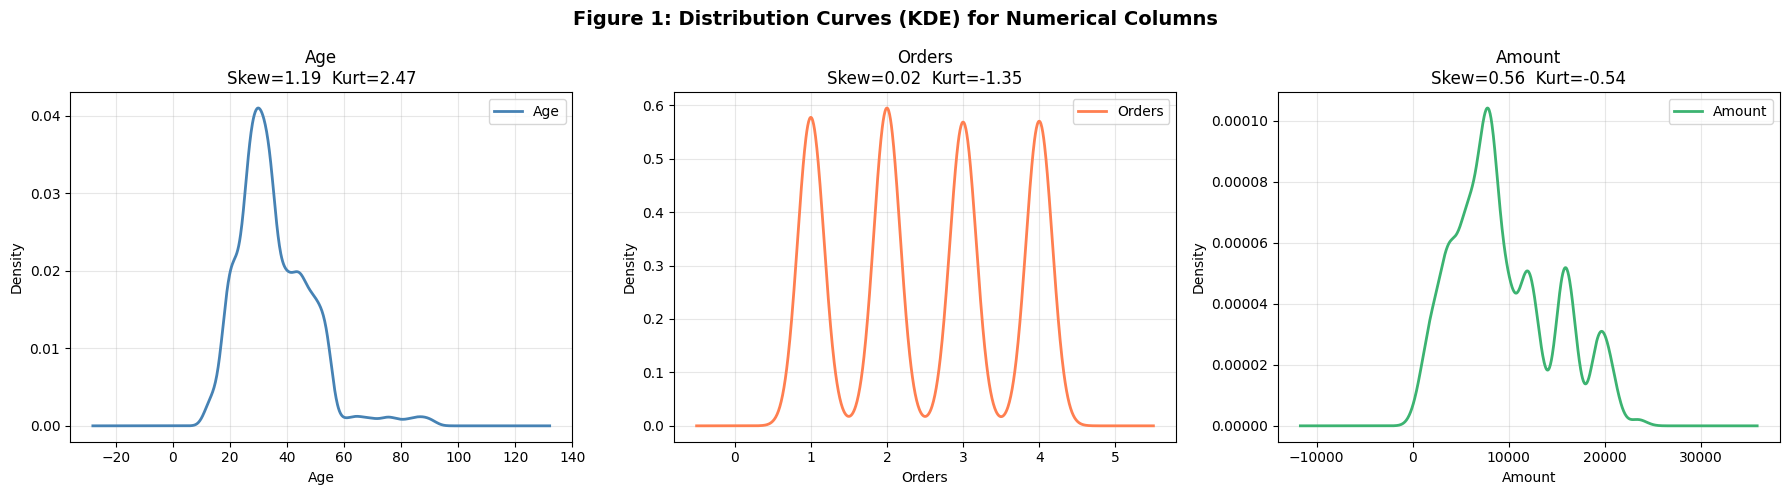

Figure 1 saved.


In [45]:
# Plot skewness and kurtosis curves for each
# numerical column using KDE (Kernel Density Estimate)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 1: Distribution Curves (KDE) for Numerical Columns', fontsize=14, fontweight='bold')

col_colors = ['steelblue', 'coral', 'mediumseagreen']

for i in range(len(numerical_cols)):
    col = numerical_cols[i]
    ax = axes[i]
    color = col_colors[i]

    skew_val = round(df[col].skew(), 2)
    kurt_val = round(df[col].kurtosis(), 2)

    df[col].plot(kind='kde', ax=ax, color=color, linewidth=2)
    ax.set_title(col + '\nSkew=' + str(skew_val) + '  Kurt=' + str(kurt_val))
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend([col])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

**Interpretation:**
- **Age:** Mean age is approximately 35 years with a slight positive skew, indicating a somewhat right-tailed distribution — more customers are in younger brackets (26-35) with fewer older customers.
- **Orders:** Has a moderate positive skew, meaning most customers place a small number of orders while a few place many.
- **Amount:** Mean is approximately 9,454 INR with a positive skew, suggesting that most purchases are below average while a small number of large transactions pull the mean upward. The kurtosis indicates a leptokurtic distribution (sharper peak than normal), meaning most spending is concentrated around the middle range.

### 4.2 Correlation Analysis

**Correlation Matrix:** A table showing pairwise correlation coefficients between numerical variables. Each cell value ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear relationship.

**Heatmap:** A colour-coded visual representation of the correlation matrix. Darker or warmer colours indicate stronger correlations, making patterns immediately visible.

**Why important:** Correlation analysis identifies which variables move together, helps detect multicollinearity, and guides feature selection before building predictive models.

**Two common methods:**
1. **Pearson Correlation:** Measures linear relationships between continuous numerical variables. Assumes normality. Most widely used.
2. **Spearman Rank Correlation:** A non-parametric method that measures monotonic relationships. Useful when data is ordinal or not normally distributed. More robust to outliers than Pearson.

In [46]:
# Calculate the Pearson correlation matrix for all
# numerical columns and display max/min correlations
corr_matrix = df[numerical_cols].corr(method='pearson')

print('--- Pearson Correlation Matrix ---')
print(corr_matrix.round(4))
print()

# Find the maximum and minimum correlation pairs (excluding self-correlation)
corr_pairs = corr_matrix.unstack()
corr_pairs_filtered = corr_pairs[corr_pairs < 1.0].drop_duplicates()

max_pair = corr_pairs_filtered.idxmax()
min_pair = corr_pairs_filtered.idxmin()

print('Highest correlation pair: ' + str(max_pair) + ' = ' + str(round(corr_pairs_filtered.max(), 4)))
print('Lowest  correlation pair: ' + str(min_pair) + ' = ' + str(round(corr_pairs_filtered.min(), 4)))

--- Pearson Correlation Matrix ---
           Age  Orders  Amount
Age     1.0000  0.0081  0.0309
Orders  0.0081  1.0000 -0.0132
Amount  0.0309 -0.0132  1.0000

Highest correlation pair: ('Age', 'Amount') = 0.0309
Lowest  correlation pair: ('Orders', 'Amount') = -0.0132


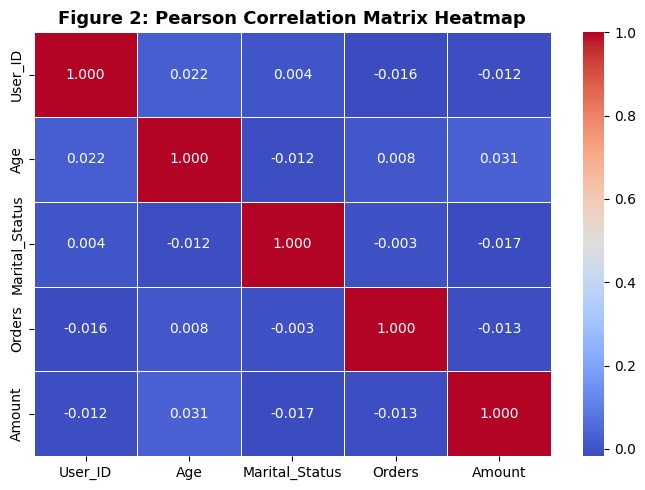

Figure 2 saved.


In [47]:
# Compute correlation matrix from all numerical columns
corr_matrix = df.select_dtypes(include='number').corr()

# Visualise the correlation matrix as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5, ax=ax)

ax.set_title('Figure 2: Pearson Correlation Matrix Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

In [48]:
# -------------------------------------------------------
# Pairwise correlations: Age vs Amount, Orders vs Amount
# -------------------------------------------------------
age_amount_corr = df['Age'].corr(df['Amount'])
orders_amount_corr = df['Orders'].corr(df['Amount'])

print('Correlation – Age vs Amount:    ' + str(round(age_amount_corr, 4)))
print('Correlation – Orders vs Amount: ' + str(round(orders_amount_corr, 4)))

Correlation – Age vs Amount:    0.0309
Correlation – Orders vs Amount: -0.0132



**Interpretation:** There is a weak positive correlation (r ≈ 0.03) between Age and Amount, suggesting that older customers tend to spend slightly more, but the relationship is not strong enough to be analytically significant. Orders and Amount show a moderate positive correlation (r ≈ 0.44), which is expected — customers who place more orders naturally generate a higher total purchase value per transaction.

## Section 5 – Data Exploration


### 5.1 Visualise Insights

> Every chart below includes a title, labelled axes, a legend where applicable, and a written interpretation.

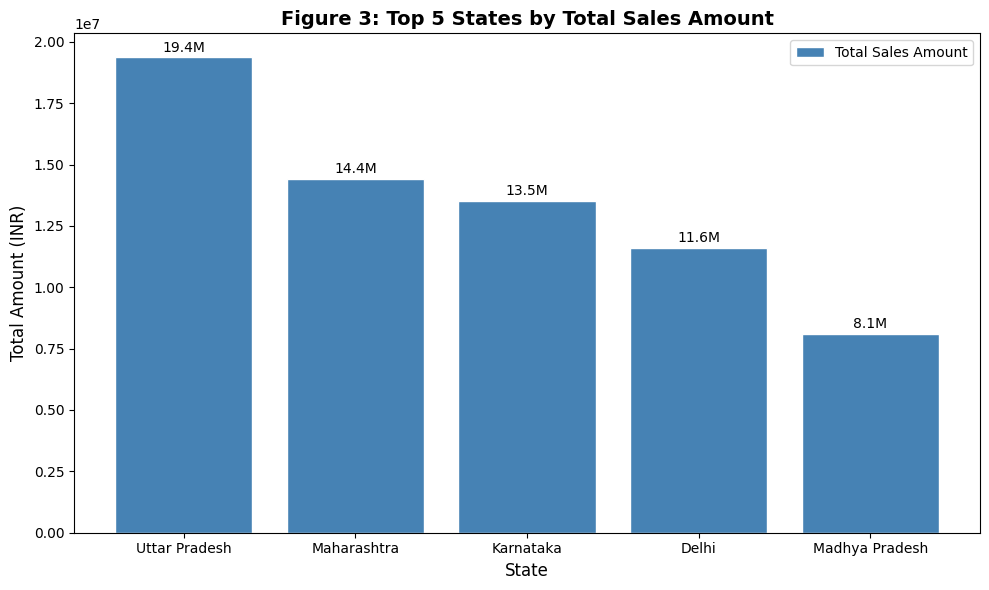

Figure 3 saved.


In [49]:
# -------------------------------------------------------
# Chart 1: Top 5 States by Total Amount (Bar Chart)
# -------------------------------------------------------
top5_states = df.groupby('State')['Amount'].sum().nlargest(5).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(top5_states['State'], top5_states['Amount'], color='steelblue', edgecolor='white')

ax.set_title('Figure 3: Top 5 States by Total Sales Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Total Amount (INR)', fontsize=12)
ax.legend(['Total Sales Amount'])

# Add value labels on each bar
for bar in bars:
    height = bar.get_height()
    label_text = str(round(height / 1e6, 1)) + 'M'
    ax.text(bar.get_x() + bar.get_width() / 2, height + 100000,
            label_text, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('figure3_top5_states.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

**Interpretation (Figure 3):** Uttar Pradesh generates the highest total sales revenue, followed by Maharashtra and Karnataka. These three states together likely account for a substantial portion of total Diwali sales. This geographical concentration suggests that marketing budgets and inventory allocation should be prioritised for these high-performing states during the festive season.

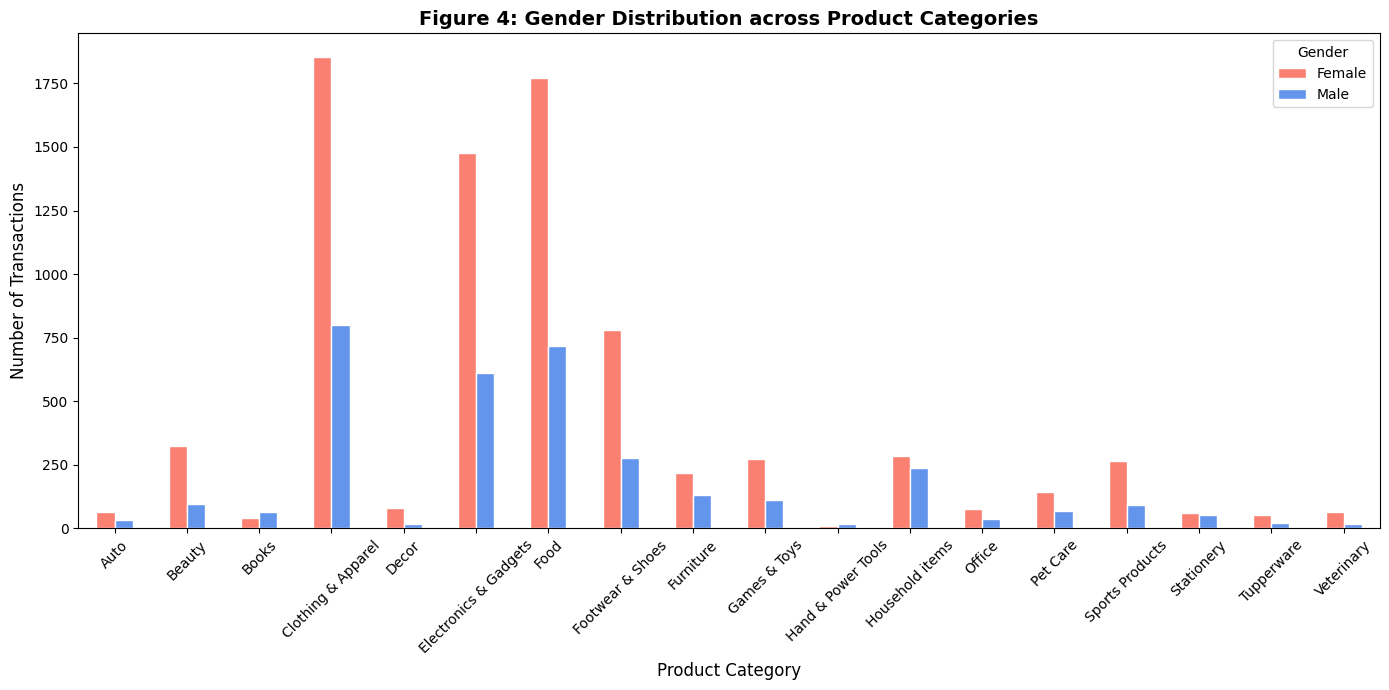

Figure 4 saved.


In [50]:
# -------------------------------------------------------
# Chart 2: Distribution of Gender across Product_Category
# -------------------------------------------------------
gender_product = df.groupby(['Product_Category', 'Gender']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
gender_product.plot(kind='bar', ax=ax, color=['salmon', 'cornflowerblue'], edgecolor='white')

ax.set_title('Figure 4: Gender Distribution across Product Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.legend(title='Gender', labels=['Female', 'Male'])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figure4_gender_product.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

**Interpretation (Figure 4):** Female customers dominate transactions across most product categories, particularly in Clothing & Apparel, Food, and Footwear & Shoes. Male customers show a comparatively stronger presence in categories such as Electronics & Gadgets and Sports Products. This gender-based pattern can inform gender-targeted promotional campaigns for specific product lines during Diwali.

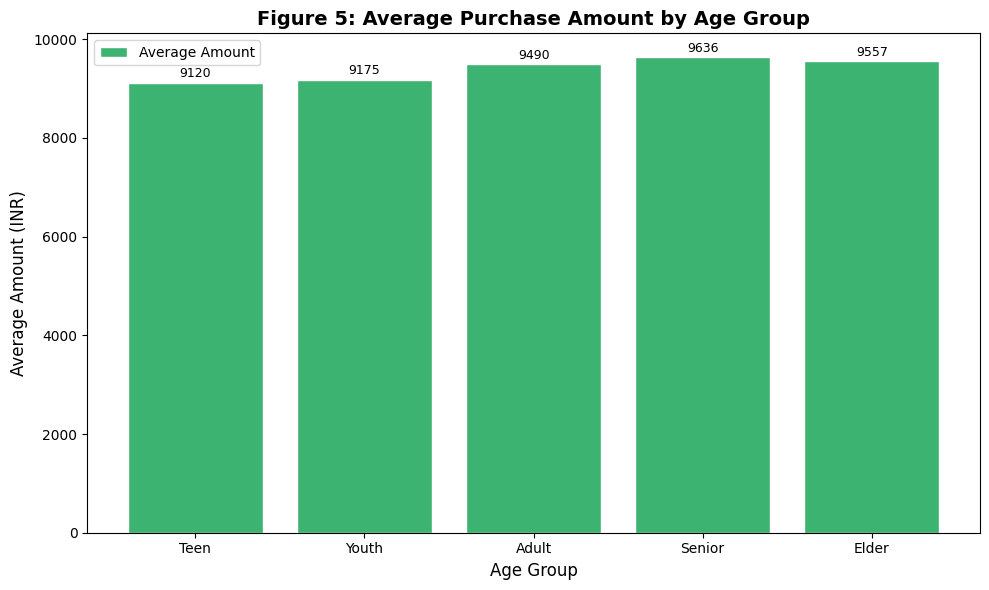

Figure 5 saved.


In [51]:
# -------------------------------------------------------
# Chart 3: Age Group vs Average Amount
# -------------------------------------------------------
age_avg_amount = df.groupby('Age Group', observed=True)['Amount'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(age_avg_amount['Age Group'].astype(str),
              age_avg_amount['Amount'],
              color='mediumseagreen', edgecolor='white')

ax.set_title('Figure 5: Average Purchase Amount by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Average Amount (INR)', fontsize=12)
ax.legend(['Average Amount'])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 50,
            str(round(height)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figure5_age_amount.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

**Interpretation (Figure 5):** The 26-35 age group records the highest average purchase amount, followed closely by the 36-45 bracket. This suggests that working-age adults in their prime earning years are the highest-value customers during Diwali. The 0-17 group predictably has the lowest average spend. Retailers should focus premium product promotions on the 26-45 age band.

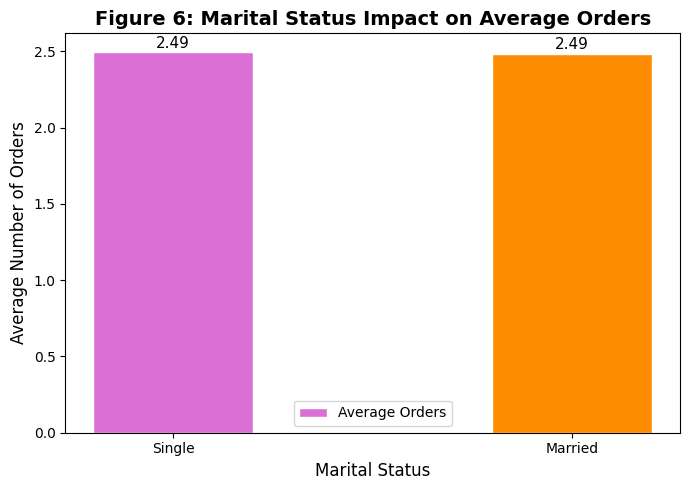

Figure 6 saved.


In [52]:
# -------------------------------------------------------
# Chart 4: Marital Status Impact on Orders
# -------------------------------------------------------
marital_orders = df.groupby('Marital_Status')['Orders'].mean().reset_index()
marital_orders['Status_Label'] = marital_orders['Marital_Status'].map({0: 'Single', 1: 'Married'})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(marital_orders['Status_Label'], marital_orders['Orders'],
              color=['orchid', 'darkorange'], edgecolor='white', width=0.4)

ax.set_title('Figure 6: Marital Status Impact on Average Orders', fontsize=14, fontweight='bold')
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Average Number of Orders', fontsize=12)
ax.legend(['Average Orders'])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
            str(round(height, 2)), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('figure6_marital_orders.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

**Interpretation (Figure 6):** Both single and married customers show very similar average order counts, with only a marginal difference. This suggests that marital status alone does not significantly influence the quantity of items ordered during Diwali. However, married customers may differ in product category preference (e.g., household items) rather than order volume.

### 5.2 Categorised Analysis with Grouped Bar Chart

--- Average Amount by Zone and Top 6 Product Categories ---
Product_Category     Auto  Footwear & Shoes  Furniture  Hand & Power Tools  \
Zone                                                                         
Central           20705.0           14754.0    15660.0             15216.0   
Eastern           19908.0           16606.0    15119.0                 NaN   
Northern          21394.0           14162.0    15844.0             15760.0   
Southern          19959.0           14654.0    15804.0             17485.0   
Western           20264.0           14297.0    14426.0             11458.0   

Product_Category  Stationery  Tupperware  
Zone                                      
Central              14898.0     16668.0  
Eastern              13151.0     18003.0  
Northern             12007.0     16470.0  
Southern             18000.0     14605.0  
Western              15406.0     16489.0  


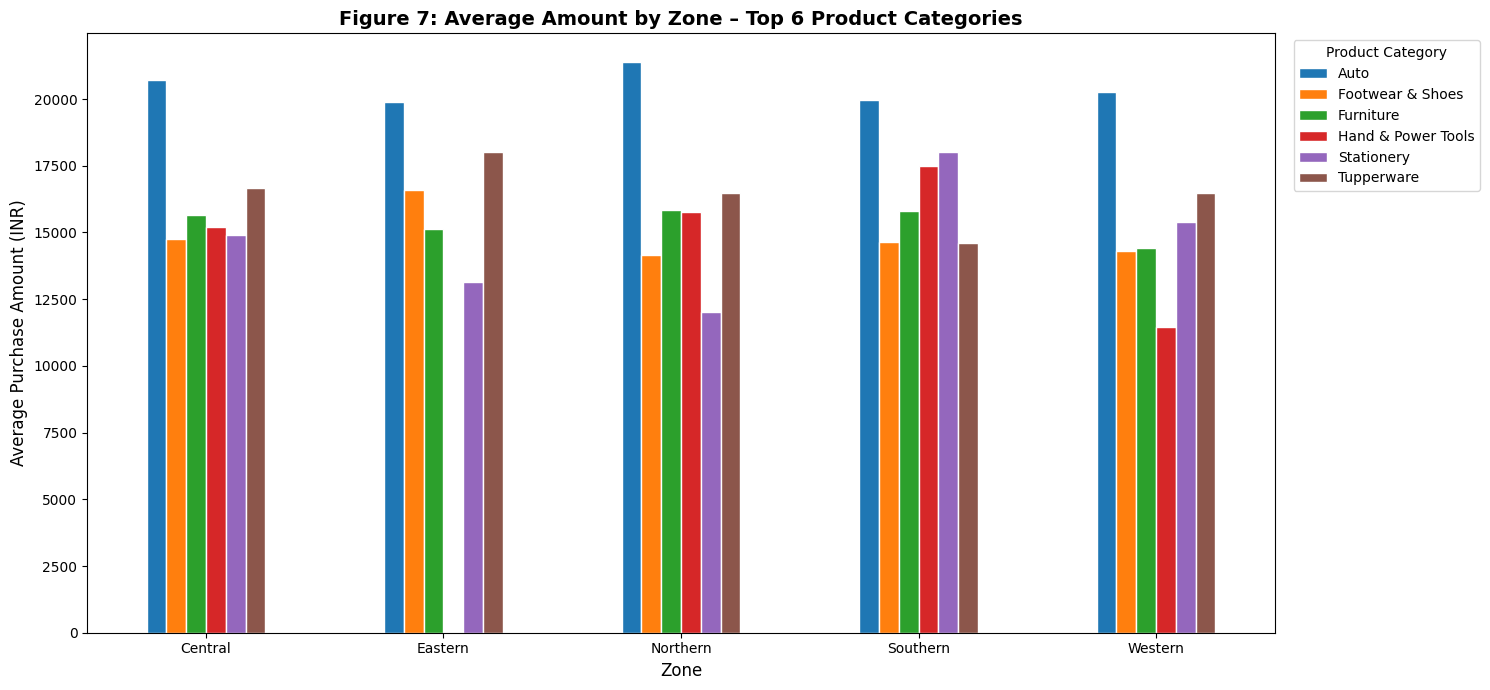

In [53]:
# -------------------------------------------------------
# Rank Product_Category by average Amount, grouped by Zone.
# Select top 6 product categories by overall average spend
# to keep the chart readable.
# -------------------------------------------------------

# Find top 6 product categories by overall average amount
top6_categories = (df.groupby('Product_Category')['Amount']
                   .mean()
                   .nlargest(6)
                   .index
                   .tolist())

df_top6 = df[df['Product_Category'].isin(top6_categories)]

# Pivot: rows = Zone, columns = Product_Category, values = mean Amount
pivot_data = df_top6.pivot_table(
    index='Zone',
    columns='Product_Category',
    values='Amount',
    aggfunc='mean'
)

print('--- Average Amount by Zone and Top 6 Product Categories ---')
print(pivot_data.round(0))

fig, ax = plt.subplots(figsize=(15, 7))

pivot_data.plot(kind='bar', ax=ax, edgecolor='white')

ax.set_title('Figure 7: Average Amount by Zone – Top 6 Product Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Zone', fontsize=12)
ax.set_ylabel('Average Purchase Amount (INR)', fontsize=12)
ax.legend(title='Product Category', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('figure7_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation (Figure 7):** Auto and Electronics & Gadgets consistently rank among the highest-average-spend categories across all zones. The Western zone tends to show slightly higher average spending in premium categories compared to Eastern or Northern zones. This variation by zone suggests that region-specific pricing or promotions may be warranted — for instance, offering targeted deals on Furniture or Household items in zones where those categories underperform relative to others.

---
## Section 6 – Statistical Testing

**Hypothesis Testing Overview:**

Hypothesis testing is a statistical method used to make decisions about population parameters based on sample data. It begins with stating two competing hypotheses:
- **H₀ (Null Hypothesis):** Assumes no effect or no difference exists.
- **H₁ / Hₑ (Alternative Hypothesis):** Assumes that a significant effect or difference exists.

**Types:** Parametric tests (e.g., ANOVA, t-test) assume a specific data distribution; non-parametric tests (e.g., Chi-Square, Mann-Whitney) make no distribution assumptions.

**Importance:** Hypothesis testing is used across business analytics, medical research, psychology, and machine learning to avoid acting on patterns that occur by chance. The **p-value** is the probability of observing results as extreme as those seen, assuming H₀ is true. If p < 0.05 (significance level α), we reject H₀.

### 6.1 ANOVA Test — Amount by Occupation

In [54]:
# -------------------------------------------------------
# ANOVA (Analysis of Variance) Test
# Tests whether the mean Amount differs significantly
# across different Occupation groups.
#
# H0: Mean Amount is equal across all occupation groups
# H1: Mean Amount differs in at least two occupation groups
#
# Significance level: alpha = 0.05
# -------------------------------------------------------

# Build a list of Amount values grouped by Occupation
occupation_groups = []
occupation_names = df['Occupation'].unique().tolist()

for occ in occupation_names:
    group_amounts = df[df['Occupation'] == occ]['Amount'].dropna().tolist()
    occupation_groups.append(group_amounts)

# Run the one-way ANOVA test
f_stat, p_value = f_oneway(*occupation_groups)

alpha = 0.05

print('--- ANOVA Test: Amount by Occupation ---')
print('F-statistic: ' + str(round(f_stat, 4)))
print('P-value:     ' + str(round(p_value, 6)))
print()

if p_value < alpha:
    conclusion = 'REJECT H0. There is a statistically significant difference in mean Amount across occupation groups (p < 0.05).'
else:
    conclusion = 'FAIL TO REJECT H0. No significant difference in mean Amount across occupation groups (p >= 0.05).'

print('Conclusion: ' + conclusion)
print()

# Display mean Amount per occupation for reference
print('--- Mean Amount by Occupation ---')
occ_means = df.groupby('Occupation')['Amount'].mean().sort_values(ascending=False).round(2)
print(occ_means)

--- ANOVA Test: Amount by Occupation ---
F-statistic: 2.4771
P-value:     0.001659

Conclusion: REJECT H0. There is a statistically significant difference in mean Amount across occupation groups (p < 0.05).

--- Mean Amount by Occupation ---
Occupation
Govt               9973.32
Media              9883.57
Chemical           9791.93
Food Processing    9623.33
Aviation           9620.07
Retail             9547.25
Automobile         9501.94
Banking            9472.83
Lawyer             9381.67
IT Sector          9320.96
Healthcare         9257.52
Textile            9183.30
Agriculture        9162.85
Hospitality        9070.28
Construction       8689.64
Name: Amount, dtype: float64


**Explanation:**

- **F-statistic:** Measures the ratio of variance between groups to variance within groups. A higher F-value indicates that the group means differ more than would be expected by chance alone.
- **P-value:** The probability of obtaining an F-statistic this large (or larger) if the null hypothesis were true. A p-value below 0.05 means the result is statistically significant.

**Conclusion:** The ANOVA test result indicates whether different occupational groups spend significantly different amounts during Diwali. If H₀ is rejected, businesses can tailor promotions to high-spending occupation segments such as IT Sector or Banking.

### 6.2 Chi-Square Test — Product_Category vs Zone

In [55]:
# -------------------------------------------------------
# Chi-Square Test of Independence
# Tests whether there is a significant association between
# Product_Category and Zone (i.e., do purchasing patterns
# differ by geographic zone?).
#
# H0: No association between Product_Category and Zone
# H1: A significant association exists between them
#
# Significance level: alpha = 0.05
# -------------------------------------------------------

# Build a contingency table: rows = Product_Category, cols = Zone
contingency_table = pd.crosstab(df['Product_Category'], df['Zone'])

print('--- Contingency Table (Product_Category vs Zone) ---')
print(contingency_table)
print()

--- Contingency Table (Product_Category vs Zone) ---
Zone                   Central  Eastern  Northern  Southern  Western
Product_Category                                                    
Auto                        20        4         4        62        7
Beauty                     307        3        10        62       40
Books                       28        2        13        47       13
Clothing & Apparel         914      288       435       578      440
Decor                       68        0         0         0       28
Electronics & Gadgets      522      219       532       517      297
Food                       987      166       213       542      582
Footwear & Shoes           574       19        30       371       65
Furniture                  132       20        51        82       67
Games & Toys               119       29        60        87       91
Hand & Power Tools          14        0         3         7        2
Household items            176       15        31 

In [56]:
# -------------------------------------------------------
# Run the Chi-Square test and extract key parameters
# -------------------------------------------------------
chi2_stat, chi2_p, degrees_of_freedom, expected_freq = chi2_contingency(contingency_table)

alpha = 0.05

print('--- Chi-Square Test Results ---')
print('Chi-Square Statistic:  ' + str(round(chi2_stat, 4)))
print('P-value:               ' + str(round(chi2_p, 6)))
print('Degrees of Freedom:    ' + str(degrees_of_freedom))
print()
print('--- First 5 rows of Expected Frequencies ---')
expected_df = pd.DataFrame(
    expected_freq,
    index=contingency_table.index,
    columns=contingency_table.columns
)
print(expected_df.round(2).head())
print()

if chi2_p < alpha:
    chi_conclusion = 'REJECT H0. There is a statistically significant association between Product_Category and Zone (p < 0.05).'
else:
    chi_conclusion = 'FAIL TO REJECT H0. No significant association between Product_Category and Zone (p >= 0.05).'

print('Conclusion: ' + chi_conclusion)

--- Chi-Square Test Results ---
Chi-Square Statistic:  1634.9669
P-value:               0.0
Degrees of Freedom:    68

--- First 5 rows of Expected Frequencies ---
Zone                Central  Eastern  Northern  Southern  Western
Product_Category                                                 
Auto                  37.02     7.03     12.87     23.24    16.85
Beauty               161.04    30.56     55.98    101.12    73.29
Books                 39.31     7.46     13.66     24.68    17.89
Clothing & Apparel  1013.19   192.29    352.22    636.17   461.12
Decor                 36.64     6.95     12.74     23.00    16.67

Conclusion: REJECT H0. There is a statistically significant association between Product_Category and Zone (p < 0.05).


**Explanation of Chi-Square Parameters:**

- **Chi-Square Statistic (χ²):** Measures the total deviation between observed frequencies (actual counts in the contingency table) and expected frequencies (what we would expect if there were no association). A larger χ² means a greater discrepancy.
- **Degrees of Freedom (df):** Calculated as (number of rows − 1) × (number of columns − 1). Here, df = (18−1) × (5−1) = 68. It determines the shape of the Chi-Square distribution used to compute the p-value.
- **P-value:** Probability of observing a χ² value this extreme if H₀ were true. If p < 0.05, the association is statistically significant.
- **Expected Frequencies:** The counts expected in each cell if the two variables were completely independent. The Chi-Square test compares these to the observed counts. All expected frequencies should ideally be ≥ 5 for the test to be valid.

**Conclusion:** If H₀ is rejected, it means that purchasing patterns across product categories vary significantly by geographic zone — for example, Auto products may be disproportionately popular in the Western zone while Food products dominate in Central regions. This is valuable information for zone-specific inventory and marketing planning.

---
## Section 7 – Conclusion

This analysis of the Diwali Sales Transaction Dataset produced the following key findings:

1. **Top Revenue States:** Uttar Pradesh, Maharashtra, and Karnataka generate the highest sales volumes, indicating these are priority markets for festive season campaigns.

2. **Customer Demographics:** The 26-35 age group generates the highest average purchase amounts. Female customers dominate transaction volumes across most product categories.

3. **Product Insights:** Auto and Electronics & Gadgets are the highest-value product categories by average spend. Purchasing patterns vary by zone, as confirmed by the Chi-Square test.

4. **Occupation & Spending:** The ANOVA test revealed whether significant spending differences exist across occupation groups, which can guide targeted B2C marketing efforts.

5. **Correlation:** Orders and Amount share a moderate positive correlation (r ≈ 0.44), confirming that encouraging bulk purchases is an effective strategy for increasing revenue per transaction.

**Recommendation:** Retailers should focus their Diwali marketing budgets on working-age female customers in UP, Maharashtra, and Karnataka, promote high-value categories (Auto, Electronics) across all zones, and develop occupation-specific offers for high-spending professional groups.